---
title: "Final Project: LA Weather App with Weather Predictions"
author: "Carmen Ng"
date: "2025-3-11"
categories: [week 10, final project]
---

# LA Weather App with Weather Predictions
## Carmen Ng, Hailey Sarmiento, Victor Yao

**Link to GitHub Repo:** https://github.com/vyyao/PIC_16B_Project

Our project was to develop a web app that provides real-time, hyperlocal weather visualizations using NASA POWER API data for Los Angeles County. The app will allow users to explore weather conditions such as temperature, precipitation, wind speed, and humidity for specific locations. Users will be able to select a location and date to retrieve weather trends, compare past weather patterns, and analyze localized climate variations through interactive visualizations.

In addition to real-time and historical weather visualizations, we implemented a Keras-based neural network model to predict future weather conditions. The model is trained using historical weather data obtained from the NASA POWER API. It learns patterns in temperature, humidity, wind speed, and precipitation over time, allowing it to make short-term forecasts for a given location.

In order to implement this app we utilized a combination of Python tools and data visualization techniques. API requests (aiohttp, asyncio), plotly, machine learning (keras/tensorflow), and Dash. 

Technical tools used
1. API call with aiohttp and asyncio
2. Complex Visualization using Plotly
3. Keras Model
4. Dash

<img src="Project_images/App_flowchart.png" width=600>


In [1]:
# make sure to run these first 
# pip install aiohttp

In [2]:
# import necessary libraries first
import numpy as np
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from plotly import express as px
import plotly.graph_objs as go
from dash import Dash, html, Input, Output, Patch, dash_table
import dash_leaflet as dl
import json
from dash import Dash, dcc, html, dash_table, Input, Output, State, callback, no_update
import base64
import datetime
from datetime import date, datetime, timedelta
import io
from flask import Flask, jsonify
import asyncio
from threading import Thread
import aiohttp
import nest_asyncio
from dash.dash_table import DataTable, FormatTemplate
from dash.dash_table.Format import Format, Scheme, Trim
import dash_bootstrap_components as dbc
from scipy.interpolate import griddata

# How to run our webapp in this page
1. Download ‘final_weather_dash_app.ipynb’ (this notebook)
2. Download all .py files in ‘myProject’ folder from repository and keep it all in a folder called ‘myProject’
3. Download ‘assets’ folder (includes ‘header.css’, ‘typography.css’, and ‘custom-script.js’) and ‘california_cities_5.csv’
4. Download the 'Project_images' folder with all the .png files and and keep it all in a folder called ‘Project_images’
5. Put all files together in your desired directory.
6. Run all cells in ‘final_weather_dash_app.ipynb’

In [3]:
# import functions from module
from myProject import *

# Step 1: NASA API

To get the weather data needed for this app, we use the temporal API from NASA Power (Prediction of Worldwide Energy Sources). This provides accurate weather and climate data from NASA's satellites, and can be requested daily or hourly.

## How does the NASA API call work?

NASA Power API Documentation can be found here: https://power.larc.nasa.gov/docs/services/api/

How this API works is that you send a request to NASA's servers and they return the paramaters you ask for in a JSON format that we can use for our data visualizations and model later on. In the request, you need to specify your location (latitude and longitude), the time period (choosing between daily, hourly, or long-term averages), the weather parameters you want, and the format (here we chose JSON). 

This is the example format provided by the NASA API tutorial:
```
/api/temporal/hourly/point?parameters=T2M&community=SB&longitude=0&latitude=0&start=20170101&end=20170102&format=CSV
```

We first identified what parameters we wanted to use throughout our project by looking at the parameter dictionary. 

Parameter Dictionary can be found here: https://power.larc.nasa.gov/docs/tutorials/parameters/

We turned this into an API call `fetch_nasa_data()` that we can use to call for any location and time in our app. When the user inputs their location on the map, the map sends the coordinates to our API function, which then finds the data for the paramaters we requested. We wanted to make this call more general as we wanted to decide which parameters we wanted to call later on. We defined the paramaters we wanted to request for the app in the `get_nasa_power_hourly_data()` function. This information is then used in our visualizations.



Because, fetching data one request at a time would take too long, especially when querying multiple locations or retrieving historical data spanning years, I used aiohittp and asynchio to submit asynchronous requests. By using asynchronous requests, I was able to send multiple API calls simultaneously, reducing overall wait time.

API Call flowchart
![](Project_images/API_calls_flowchart.png)]


## How does aiohttp and asyncio work?

If you want to learn more about aiohttp and asyncio:
- aiohttp Documentation: https://docs.aiohttp.org/en/stable/
- asyncio Documentation: https://docs.python.org/3/library/asyncio.html

When making API requests, you usually use 'requests.get', which waits for each request to finish before requesting the next one. We decided to use aiohttp and asyncio to fetch multiple requests simultaneously because requesting weather data from each coordinate one by one took too long. This made making each visualization much faster from the requested data.

### What is asyncio?
asyncio is a Python library for running asynchronous tasks. It allows multiple tasks to run at the same time. It can work for API requests (what we are using it for) or for downloading files. 

Basic rundown of how to use:
1. `async def` -> defines the function (task) you want to do
2. `await` -> tells Python to wait for a task before continuing
3. `asyncio.gather()`-> runs multiple tasks at the same time

### What is aiohttp?
aiohttp works with asyncio to send multiple requests at the same time, this makes fetching API data faster because they all run at the same time. It replaces 'requests.get() for async operations. 

Basic rundown of how to use:
1. `aiohttp.ClientSession()` -> open a session to send requests
2. `async with sem` ->uses a semaphore to control the number of simultaneous API requests since NASA may timeout if too many requests are made in a certain amount of time
3. `async with session.get(url) as response` -> Fetches API data asynchronously
4. `await response.json()` -> waits for API response and converts it to JSON (automatically converts the JSON response into a Python dictionary)

In [4]:
# Apply nest_asyncio for async execution 
nest_asyncio.apply()

import inspect
print(inspect.getsource(fetch_nasa_data))


async def fetch_nasa_data(session, lat, lon, start_date, end_date, sem):
    """
    Fetches hourly weather data from the NASA POWER API asynchronously for a given location and time.

    Args:
        session (aiohttp.ClientSession): The active aiohttp session for making HTTP requests.
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        start_date (str): The start date in YYYYMMDD format.
        end_date (str): The end date in YYYYMMDD format.
        sem (asyncio.Semaphore): A semaphore to limit the number of concurrent API requests.

    Returns:
        dict: A dictionary containing the API response data, or None if an error occurs.
    """
    # request information from nasa power
    url = "https://power.larc.nasa.gov/api/temporal/hourly/point"
    
    # define the parameters that we want to call
    parameters = "PRECSNO,T2MDEW,PRECTOTCORR,T2M,WS2M,RH2M,CLOUD_AMT"
    
    # Construct the API request parameters
    params = {


# Step 2: Complex Visualizations Functions

We used the Plotly library to visualize weather data retrieved from the NASA API for the Dash app. We chose to use Plotly because it makes interactive plots which would look better in our app.

For the visualizations, we first created a line plot showing hourly updates for temperature, precipitation, and wind speed, relative humidity, and cloud cover for the user-selected location. We created the `get_nasa_power_hourly_data(lat, lon, specific_date)` function to retrieve the necessary data using the previously defined `fetch_nasa_data()` API call. This function allowed me to obtain the parameters we wanted for a specific day at the chosen location. Inputting the resulting dataframe and the attribute the user wants to visualize in the `plot_hourly(df, attr)` which will create a plot that shows the hourly trend for the attribute.

In [5]:
print(inspect.getsource(get_nasa_power_hourly_data))


async def get_nasa_power_hourly_data(lat, lon, date=None):
    """
    Fetches NASA POWER hourly weather data for a single day (default behavior).

    Args:
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        date (str, optional): The date in YYYYMMDD format. Defaults to the current date.

    Returns:
        pd.DataFrame: A DataFrame containing weather data, with datetime and relevant weather metrics.
    """

    # If no date is provided, use the current date in YYYYMMDD format
    if date is None:
        date = datetime.now().strftime("%Y%m%d")

    # Create a semaphore to limit the number of concurrent API requests (max 5 at a time)
    sem = asyncio.Semaphore(5)

    # Create an asynchronous HTTP session
    async with aiohttp.ClientSession() as session:
        # Fetch the weather data from NASA POWER API
        data = await fetch_nasa_data(session, lat, lon, date, date, sem)

    # If no data is returned or the expected data

In [6]:
# getting weather data using the API for UCLA, March 1, 2024
df = await get_nasa_power_hourly_data(34.0722, -118.4427, "20240301")
df.head()


,datetime,Snow_Precipitation,Dew_Point_2m,Total_Precipitation_mm,Temperature_2m_C,Wind_Speed_2m,Relative Humidity (%),Cloud Cover (%),Latitude,Longitude,Precipitation (in),Temperature (F),Wind Speed (mph)
0,2024-03-01 00:00:00,0.0,9.87,3.63,11.55,2.00,89.39,62.13,34.0722,-118.4427,0.142913,52.790,4.47400
1,2024-03-01 01:00:00,0.0,9.93,5.18,11.53,1.93,89.71,43.39,34.0722,-118.4427,0.203937,52.754,4.31741
2,2024-03-01 02:00:00,0.0,10.03,6.66,11.58,1.98,90.08,51.10,34.0722,-118.4427,0.262205,52.844,4.42926
3,2024-03-01 03:00:00,0.0,10.23,6.66,11.69,2.18,90.59,50.58,34.0722,-118.4427,0.262205,53.042,4.87666
4,2024-03-01 04:00:00,0.0,10.42,6.63,11.89,2.35,90.57,50.06,34.0722,-118.4427,0.261024,53.402,5.25695


In [7]:
print(inspect.getsource(plot_hourly))

def plot_hourly(df, attr):
    """
    Generates a line plot of an hourly weather attribute over time.

    Args:
        df (pd.DataFrame): The DataFrame containing the weather data.
        attr (str): The weather attribute to plot 

    Returns:
        fig: A figure displaying the hourly trends for the selected attribute.
    """
    # create a line plot on plotly using weather dataframe
    # x is the time while y is the attribute the user chooses
    fig = px.line(df, 
                  x="datetime", y=attr, 
                  title=f"Hourly {attr} Trends",
                  labels={"datetime": "Datetime"},
                  line_shape='linear', 
                  # Set line color based on attribute type
                  color_discrete_sequence=[attr_colors[attr]])
    
    # Update the layout with x and y axis
    # x axis shows time while y axis shows weather parameter measures
    fig.update_layout(xaxis_title="Datetime", 
                      yaxis_title=attr, 
            

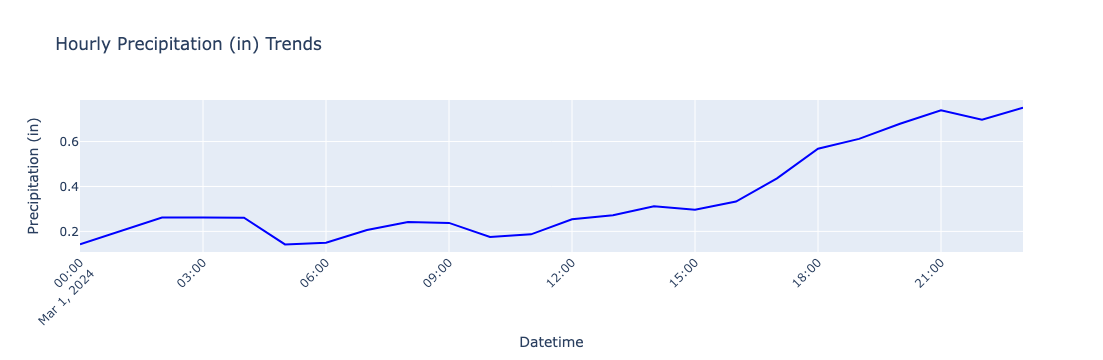

In [8]:
# plotting the hourly trends for percipitation for the day
plot_hourly(df, 'Precipitation (in)')

We also created a visualization displaying weather trends over the past ten years using box plots to allow users to see trends for different weather conditions throughout the past decade. To implement this, we created a new function call: `get_nasa_power_hourly_data_years(lat, lon, start_year, end_year)`. This function call allows me to use the `get_nasa_power_hourly_data()` to retrieve the weather data for the parameters we want from the NASA API call but for multiple years. We will use the dataframe created from this call to create a boxplot visualization for the attribute the user wants to visualize using `plot_yearly(df, attr)`.

In [9]:
print(inspect.getsource(get_nasa_power_hourly_data_years))

async def get_nasa_power_hourly_data_years(lat, lon, start_year, end_year):
    """
    Fetches NASA POWER API hourly data for multiple years.

    Args:
        lat (float): Latitude of the location.
        lon (float): Longitude of the location.
        start_year (int): The starting year of data collection.
        end_year (int): The ending year of data collection.

    Returns:
        pd.DataFrame: A DataFrame containing the weather data for multiple years
    """
    # Create a list to store asynchronous API requests
    tasks = []
    
    # loop through specified range of years
    for year in range(start_year, end_year): 
        # start January 1st of the first year
        start_date = f"{year}0101"
        # end at December 31st of the last year
        end_date = f"{min(year, end_year)}1231"
        # Add an asynchronous task to fetch weather data for this year
        tasks.append(get_nasa_power_hourly_data(lat, lon, start_date))
    
    # Execute all API requests conc

In [10]:
# get weather data for ten years
df_tenyears = await get_nasa_power_hourly_data_years(34.0722, -118.4427, 2014, 2020)
df_tenyears.head()

,datetime,Snow_Precipitation,Dew_Point_2m,Total_Precipitation_mm,Temperature_2m_C,Wind_Speed_2m,Relative Humidity (%),Cloud Cover (%),Latitude,Longitude,Precipitation (in),Temperature (F),Wind Speed (mph)
0,2014-01-01 00:00:00,0.0,1.70,0.0,12.16,2.52,52.10,14.31,34.0722,-118.4427,0.0,53.888,5.63724
1,2014-01-01 01:00:00,0.0,1.15,0.0,11.97,2.92,50.25,13.14,34.0722,-118.4427,0.0,53.546,6.53204
2,2014-01-01 02:00:00,0.0,0.67,0.0,11.76,3.24,48.75,2.79,34.0722,-118.4427,0.0,53.168,7.24788
3,2014-01-01 03:00:00,0.0,0.33,0.0,11.66,3.59,47.57,20.20,34.0722,-118.4427,0.0,52.988,8.03083
4,2014-01-01 04:00:00,0.0,0.09,0.0,11.65,3.95,46.44,20.86,34.0722,-118.4427,0.0,52.970,8.83615


In [11]:
print(inspect.getsource(plot_yearly))

def plot_yearly(df, attr):
    """
    Generates a box plot to visualize yearly trends of a weather attribute.

    Args:
        df (pd.DataFrame): The DataFrame containing weather data.
        attr (str): The weather attribute to plot (must be a key in attr_colors).

    Returns:
        fig: A figure displaying the yearly trends of the selected attribute.
    """
    # Create a new 'year' column
    df["year"] = df["datetime"].dt.year
    
    # Create a box plot
    fig = px.box(df,
                 # x axis shows year while y is set using the attribute
                 x="year",
                 y=attr,
                 # Set color based on attribute type
                 color_discrete_sequence=[attr_colors[attr]],
                 # update labels
                 title=f"Yearly Average {attr} Trends",
                 labels={"year": "Year"})
    
    # return the figure
    return fig



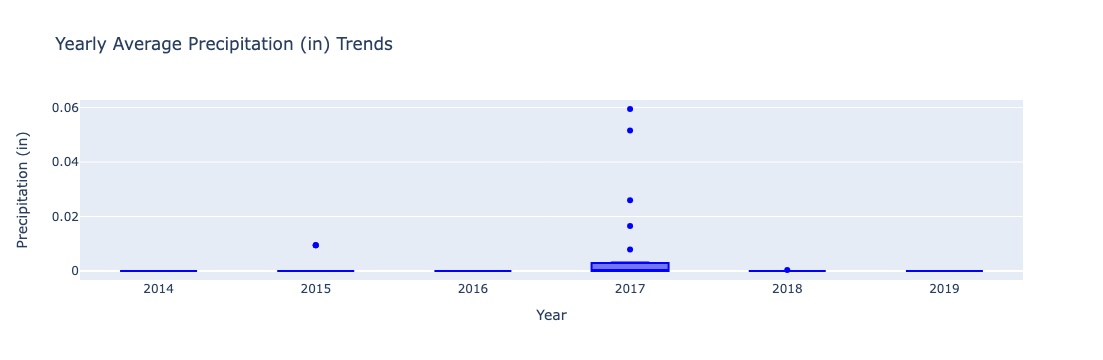

In [12]:
# plot yearly precipitation trends
plot_yearly(df_tenyears, 'Precipitation (in)')

Lastly, we created a visualization using Plotly’s choropleth map to display precipitation and temperature at random locations within a radius of the user’s selected location. We chose this approach because generating a heatmap required making API requests for every coordinate, which was not feasible. To implement this, we created a new function. The `get_nasa_power_data_nearby()` function fetches weather parameters for nearby locations after the `generate_new_locations()` function generates a set of coordinates within a 15-mile radius of the user’s chosen location. The `plot_mock_heatmap()` function takes in the attribute the user wants to visualize along with the location and calls the last two functions mentioned to get weather data for a designated number of nearby locations in a designated mile(s) radius.

In [13]:
print(inspect.getsource(generate_nearby_locations))

def generate_nearby_locations(lat, lon, radius_miles=15, num_points=10):
    """
    Generates random nearby locations within a radius using NumPy.

    Args:
    - lat (float): Latitude of the center point.
    - lon (float): Longitude of the center point.
    - radius_miles (float): Search radius in miles.
    - num_points (int): Number of locations to generate.

    Returns:
    - NumPy array of shape (num_points, 2) with latitude and longitude values.
    """
    # Generate random angles uniformly between 0 and 2π
    angles = np.random.uniform(0, 2 * np.pi, num_points)

    # Use square root scaling to distribute points uniformly across the circle
    distances = radius_miles * np.sqrt(np.random.uniform(0, 1, num_points))

    # Convert polar coordinates (distance, angle) to latitude & longitude offsets
    delta_lat = (distances / 69) * np.cos(angles)
    delta_lon = (distances / (69 * np.cos(np.radians(lat)))) * np.sin(angles)

    # Compute new latitudes and longitudes
    new_

In [14]:
print(inspect.getsource(get_nasa_power_data_nearby))


async def get_nasa_power_data_nearby(lat, lon, date=None, num_locations=10, radius_miles=15):
    """
    Fetches NASA POWER API hourly data for multiple nearby locations for a single day.

    Args:
        lat (float): Latitude of the central location.
        lon (float): Longitude of the central location.
        date (str, optional): Date in "YYYYMMDD" format. Defaults to today.
        num_locations (int, optional): Number of nearby locations to generate. Default is 10.
        radius_miles (float, optional): Radius in miles to generate nearby locations. Default is 15.

    Returns:
        pd.DataFrame or None: A Pandas DataFrame containing weather data for all locations
    """
    # If no date is provided, use today's date in YYYYMMDD format
    if date is None:
        date = datetime.now().strftime("%Y%m%d")
        
    # Generate a list of random nearby locations within the specified radius
    locations = generate_nearby_locations(lat, lon, radius_miles, num_locations)
  

In [15]:
# get weather data for 50 locations nearby
df_nearby_one_day = await get_nasa_power_data_nearby(34.0722, -118.4427, "20240301", num_locations=50)
df_nearby_one_day.head()

,datetime,Snow_Precipitation,Dew_Point_2m,Total_Precipitation_mm,Temperature_2m_C,Wind_Speed_2m,Relative Humidity (%),Cloud Cover (%),Latitude,Longitude,Precipitation (in),Temperature (F),Wind Speed (mph)
0,2024-03-01 00:00:00,0.0,9.87,3.63,11.55,2.00,89.39,62.13,34.084469,-118.483719,0.142913,52.790,4.47400
1,2024-03-01 01:00:00,0.0,9.93,5.18,11.53,1.93,89.71,43.39,34.084469,-118.483719,0.203937,52.754,4.31741
2,2024-03-01 02:00:00,0.0,10.03,6.66,11.58,1.98,90.08,51.10,34.084469,-118.483719,0.262205,52.844,4.42926
3,2024-03-01 03:00:00,0.0,10.23,6.66,11.69,2.18,90.59,50.58,34.084469,-118.483719,0.262205,53.042,4.87666
4,2024-03-01 04:00:00,0.0,10.42,6.63,11.89,2.35,90.57,50.06,34.084469,-118.483719,0.261024,53.402,5.25695


In [16]:
print(inspect.getsource(plot_mock_heatmap))

def plot_mock_heatmap(attr, lat, lon, date=None, num_locations=50, radius_miles=15):
    """
    Fetches weather data for locations in a specified radius and plots a scatter map 
    showing temperature, precipitation, or other weather attributes.

    Args:
        attr (str): The weather attribute to visualize.
        lat (float): Latitude of the central location.
        lon (float): Longitude of the central location.
        date (str, optional): Date in "YYYYMMDD" format. Defaults to today.
        num_locations (int, optional): Number of nearby locations to generate.
        radius_miles (float, optional): Radius in miles for generating nearby locations.

    Returns:
        fig: A scatter map visualization of the selected weather attribute.
    """
    from .API_calls import (fetch_nasa_data, get_nasa_power_hourly_data, 
                        get_nasa_power_hourly_data_years, 
                        generate_nearby_locations, 
                        get_nasa_power_data_nea

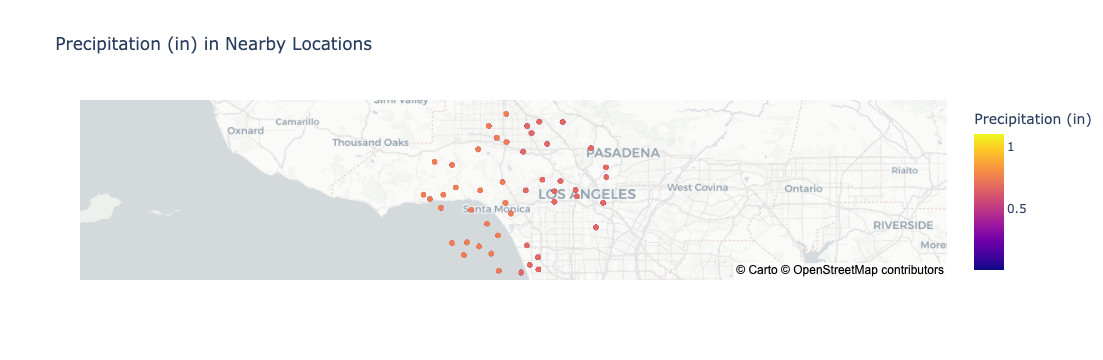

In [17]:
# plot precipitation for nearby locations
plot_mock_heatmap('Precipitation (in)', 34.0722, -118.4427, "20240301")

Lastly, we created a map visualization to display precipitation and temperature at random locations within a radius of the user’s selected location. We chose this approach because generating a true heatmap required making API requests for every coordinate, which was not feasible. To implement this, we created a new function. The `get_nasa_power_data_nearby` function fetches weather parameters for nearby locations using `get_nasa_power_hourly_data`, after the `generate_new_locations function` generates a set of coordinates within a 15-mile radius of the user’s chosen location. 

Since the data points are scattered, we used SciPy’s griddata function to interpolate values across a 150x150 grid, creating a smooth heatmap. First, we applied cubic interpolation to estimate values between known points, but since cubic interpolation can fail in areas with fewer data points, we used nearest-neighbor interpolation to fill any missing values. If gaps still remained, we replaced them with the dataset’s median value to prevent distortions. The heatmap was then visualized using Plotly’s Densitymapbox, which overlays the interpolated data on a Mapbox base map. 

Additionally, we used Scattermapbox to plot the original data points, ensuring users can compare real and interpolated values. We realize that if the user zooms in too much, the interpolation can fail due to insufficient data points, causing large areas of NaN values that appear as purple regions on the map. To avoid this, the user may need to zoom out to ensure enough data points are available for interpolation.

In [18]:
print(inspect.getsource(plot_heatmap))

def plot_heatmap(attr, lat, lon, date=None, num_locations=50, radius_miles=15):
    """
    Fetches weather data for nearby locations, applies interpolation, and overlays a 
    generated heatmap on a map.

    Args:
        attr (str): The weather attribute to visualize (e.g., temperature, precipitation).
        lat (float): Latitude of the central location.
        lon (float): Longitude of the central location.
        date (str, optional): Date in "YYYYMMDD" format. Defaults to today.
        num_locations (int, optional): Number of nearby locations to generate.
        radius_miles (float, optional): Radius in miles for generating nearby locations.

    Returns:
        fig: A Mapbox heatmap visualization.
    """
    from .API_calls import (fetch_nasa_data, get_nasa_power_hourly_data, 
                        get_nasa_power_hourly_data_years, 
                        generate_nearby_locations, 
                        get_nasa_power_data_nearby)
    
    # Fetch weather data asy

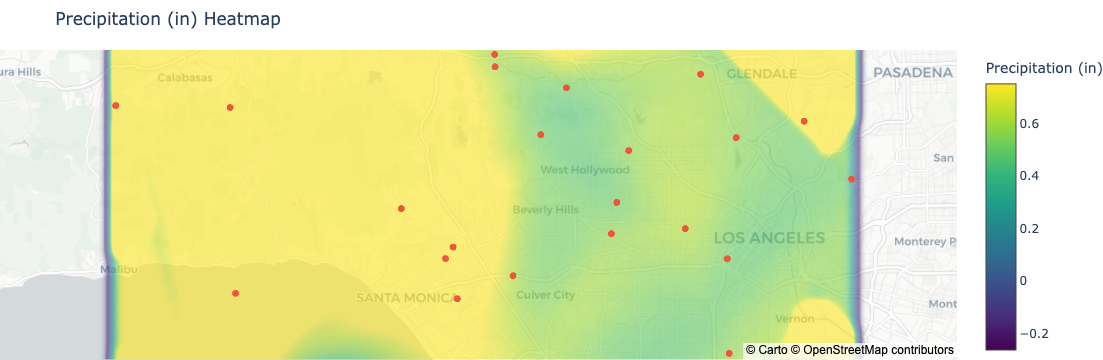

In [19]:
plot_heatmap('Precipitation (in)', 34.0722, -118.4427, "20240301")

# Step 3: Keras Model to Predict Upcoming Weather

So how are we actually going to get the weather predictions that we will be showing in the app? Well, the next step is building the predictive model. This model is a key part of our web app, enabling users to anticipate future weather patterns based on historical data. To achieve this, we implemented a Bidirectional LSTM model on the Keras/Tensorflow platform, which learns from past weather data to predict upcoming values for a selected feature, such as temperature, wind speed, or humidity.

## How the Model Works

The run_model() function builds and trains a deep learning model using Long Short-Term Memory (LSTM) networks to make weather predictions. Below is a breakdown of its key steps:

### Data Preprocessing

Before training the model, we need to prepare the input data.
- Handling Missing Data:
    - The function first removes any missing values in the selected weather feature using dropna(), ensuring that only valid data points are included in training.
- Extracting Feature Values:
    - The selected feature (e.g., temperature) is extracted from the dataset as a NumPy array. This isolates the data we want the model to learn from.
- Normalization with MinMaxScaler:
    - Since neural networks perform best when inputs are scaled, the values are normalized to the range (0,1) using MinMaxScaler. This helps stabilize training and prevents certain values from dominating the learning process.



### Creating Training Sequences

To make predictions, the model needs to learn from sequences of past weather data.
- Defining input (x_train) and output (y_train) sequences:
    - The function slides over the dataset, creating input-output pairs.
    - Each input sequence consists of n_past days of data.
    - The corresponding output sequence consists of n_future days of values to predict.
- Converting to NumPy Arrays:
    - The input (x_train) and output (y_train) data are converted into NumPy arrays and reshaped to match the LSTM input format, which requires a 3D shape (samples, time steps, features).


### Building the Neural Network

The model is structured using multiple LSTM layers, designed to capture long-term dependencies in time series data.
- Bidirectional LSTM Layer:
    - The first layer is a Bidirectional LSTM, meaning it processes data both forward and backward, capturing more patterns in the time series.
- Stacked LSTM Layers with Dropout:
    - Additional LSTM layers follow, each with dropout layers to reduce overfitting.
    - These layers help the model generalize better to unseen weather patterns.
- Dense Output Layer:
    - The final layer is a fully connected Dense layer with a linear activation function. This ensures the model outputs continuous numerical predictions.
    
    
### Training the Model

Once the architecture is built:
- Compilation:
    - The model is compiled with:
        - adam optimizer for efficient gradient updates.
        - mean_squared_error (MSE) as the loss function, ideal for regression tasks.
        - accuracy as a metric. But, it is likely not the best metric for this task, as it focuses on a perfect match between the real and predicted features, which is not feasible and not necessary for our level of forecast. This can be seen in low accuracy levels when training the model, yet the graphs show the predicted values follow the real values well.
- Training:
    - The model is trained using 20 epochs and a batch size of 32. This determines how many times the model sees the data and how many samples it processes at once. These values were decided after testing different combinations and selecting the one that had good efficiency and performance.
    
    
### Making Predictions

Once trained, the model is used to predict future weather values.
- Preparing Test Data:
    - The function extracts the most recent n_past values and scales them using the same MinMaxScaler.
- Model Prediction:
    - The trained model predicts n_future worth of values, which are then inverse-transformed to restore the original scale for easier visualizations and more interpretable results/

In [20]:
print(inspect.getsource(run_model))

def run_model(dataset, feature, n_past=50, n_future=7):
    """
    Trains a Bidirectional LSTM model to predict the next
    "n_future" units of time of a given weather feature based on
    "n_past" units of time of historical data.

    Args:
    dataset (DataFrame): Pandas DataFrame containing historical weather data.
    feature (str): Column name of the feature to be predicted.
    n_past (int, optional): Number of past time units(usually days)
        to use for training. Default 50.
    n_future (int, optional): Number of future time units(usually days)
        to predict. Default 7.

    Returns:
    real_temperature (DataFrame): DataFrame containing the last "n_past"
        units of time of actual feature values.
    predicted_temperature (ndarray): Array containing predicted values
        for the next "n_future" units of time.
    """
    feature = feature
    # Drop rows with missing values in the selected feature
    dataset = dataset.dropna(subset=[feature])
    dataset 

## Visualizing Predicted Weather Trends

Once future weather attributes have been predicted by the model, it is important to present them in a clear and interpretable way. The function responsible for this visualization creates a line graph comparing real past weather data with model-generated forecasts. This allows users to observe how the predicted values align with historical trends and anticipate upcoming weather patterns.

We begin by labeling the real weather data, which comes directly from the NASA API. This distinction ensures that past observations and future predictions remain clearly identifiable in the final visualization. The next step is to generate a sequence of future timestamps corresponding to the model's predicted values. These timestamps extend just beyond the available real data, ensuring that predictions are plotted accurately in a continuous timeline.

Once the future dates have been established, they are combined with the predicted weather values in a structured dataset. This dataset consists of both real and predicted weather data, each labeled appropriately to help with differentiation in the visualization. An interactive line graph is then generated, allowing users to hover over individual data points to see precise weather values. The real and predicted values are distinguished through color coding and marker symbols, enhancing clarity.

In addition to the graphical representation, we also prepare a tabular summary of the predictions. This table presents the forecasted values alongside their respective dates in a familiar Month-Day-Year format, making it easier for users to interpret the information. We also round the predicted values so that the data in the table remains both readable and still informative enough.

In [21]:
print(inspect.getsource(plot_predictions))

def plot_predictions(attr, real, predicted, n_future):
    """
    Plots a line graph of past weather attributes over the given date range selected by
    the user and the n_future days of predicted weather attributes

    Args:
        attr (str): the weather attribute of interest to plot and predict
        real (dataframe): a dataframe with the weather attribute on a specific date
        predicted (np.array): an array of predicted weather attributes of length n_future
        n_future (int): the number of days into the future with predicted weather

    Returns:
        fig (plotly line graph): real and predicted weather attributes plotted over time
        df (dataframe): a dataframe with labeled real and predicted weather points for
            specific dates
    """
    # add real labels to weather attr of dates that came directly from nasa api database
    real["Label"] = "Real"

    # create list of n_future number of new dates the model is predicting
    new_dates = [real["da

In [22]:
df_pred = await get_nasa_power_hourly_data(34.0722, -118.4427, "20240301")

In [23]:
# run model
real, predicted = run_model(df_pred, 'Precipitation (in)', 10, 10)

# Generate the graph and DataFrame with predictions
graph, pred_df = plot_predictions('Precipitation (in)', real, predicted, 10)


Epoch 1/20


/opt/anaconda3/envs/PIC16B-25W/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - acc: 0.2000 - loss: 0.3353
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.4000 - loss: 0.3326
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.8000 - loss: 0.3297
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.6000 - loss: 0.3266
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.6000 - loss: 0.3256
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.8000 - loss: 0.3213
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - acc: 0.8000 - loss: 0.3176
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.4000 - loss: 0.3178
Epoch 9/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - acc: 0.8000 - loss: 0.3107
Epoch 10/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8000 - loss: 0.3119
Epoch 11/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8000 - loss: 0.3044
Epoch 12/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8000 - loss: 0.3029
Epoch 13/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - acc: 0.8000 - loss: 0.

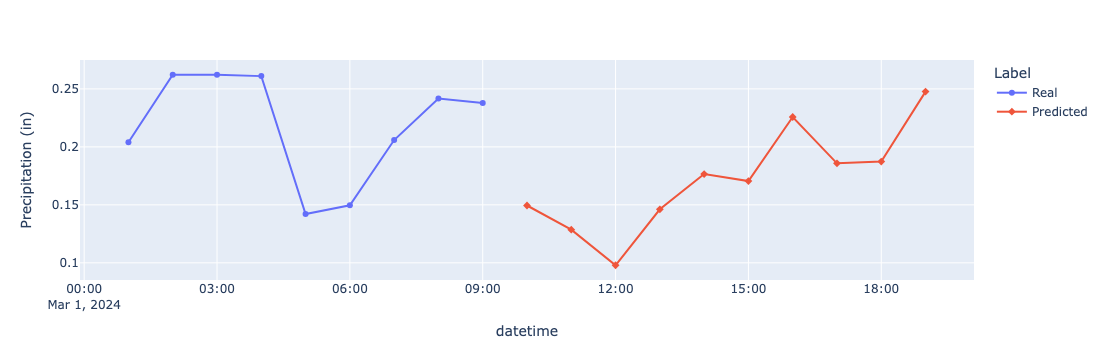

In [24]:
# Display the graph
graph.show()

Output:

![](Project_images/pred_graph.png)

# Step 4: Interactive Weather App

We decided to create an interactive dash weather app for users to explore past, present, and future weather for a desired location. There are three main tabs for users to explore: "Daily Weather", "Weather Graphs", and "Weather Predictions". We will go through each section's layout, callback, and output with the complete Dash cell below the explanations. 

## **Daily Weather**

### Layout

The first tab of the web app is meant to prompt the user for location and date parameters that are necessary for the other tabs and functions. Directions are listed at the top to help users interact with the map, date picker, and any buttons on the tab. Dash components are labeled with `dcc.Markdown` components on the webapp making it easy for users to find and understand the purpose of the dash component. When selecting a location, users have the option to zoom to a city of their choice from the dropdown city which lists major cities in California. They also have the option to zoom and pan on the `dashleaflet.Map` object themselves. The range of dates a user can select using the `dcc.DatePickerSingle` object is from the year 2000 to the end of 2024. Most recent dates from 2025 are not available because of the inconsistency in weather data availability sourced form the NASA POWER API, especially most recent days. Three `dcc.Store` components are not displayed on the web app but store the user's choice for future functions and other tabs on the web app. 

![](Project_images/tab1_default.png)

See the code for the tab "Daily Weather" below:

```python
dcc.Tab(label='Daily Weather', children=[ 
    dcc.Markdown('''
        ## Directions: 
        1. Pan and zoom in/out on the map to find your location.
        2. Click your location on the map for current weather.
            Press the "Submit" button to confirm your selection and your weather reuslts will load promptly.
        3. Check out the "Weather Graphs" and "Weather Predictions" tabs for more weather information.'''),
    dcc.Markdown("### Zoom to City"),
    dcc.Dropdown(list(ca_city_dict.keys()), id="city"),
    html.Br(),
    dcc.Markdown("### Select Location:"),
    dl.Map( 
        id='map',
        n_clicks=0,
        children=[
            dl.TileLayer()
        ],
        center=[34, -118],
        zoom=9,
        style={'height': '50vh'}
    ),
    html.Div(id='coords'),
    dcc.Markdown("### Select Date:"),
    dcc.DatePickerSingle(
        id='date-picker',
        min_date_allowed=date(2000, 1, 1),
        max_date_allowed=date(2024, 12, 31),
        initial_visible_month=date(2024, 1, 1),
    ),
    html.Button('Submit',id='submit',n_clicks=0,className="button"), 
    dcc.Markdown('## Current Weather:'),
    dcc.Markdown(id='table-caption'),
    dash_table.DataTable(id='weather',
        style_as_list_view=True,
        style_cell={'padding': '2px'},
        style_header={
            'backgroundColor': 'white',
            'fontWeight': 'bold'
        },
        style_cell_conditional=[
            {'textAlign': 'center'}
        ],
    ),
    dcc.Store(id='latitude'), # stored latitude for other tabs/functions
    dcc.Store(id='longitude'), # stored longitude for other tabs/functions
    dcc.Store(id='date'), # stored date for other tabs/function
], className="tab",)
```

### Callback

There are three callback functions associated with the "Daily Weather" tab: `map`, `zoom_to_city`, and `submit`.

**`map`** deals with user-selected locations on the `dashleaflet.Map` object. When users click the map, a `Patch()` marker is added to the `dl.Map` object. The latitude and longitude coordinates of the selected location are also extracted from the clickdata value of `dl.Map`. Multiple `Patch()` objects can be added to the `dl.Map` object and each click will return the coordinates to display below the map, the `Patch()` location marker, and the latitude and longitude values to be stored in `dcc.Store` objects. 

See the code for the callback function `map` below:

```python
@app.callback(
    Output('coords', 'children'), # output for coordinate str
    Output('map', 'children'), # output for markers
    Output('latitude','data'), # store latitude for other tabs/function
    Output('longitude','data'), # store longitude for other tabs/functions
    Input('map', 'clickData'), # update with new coords
    Input('map', 'n_clicks'), # update with new clicks
    prevent_initial_call=True
)
def map(click_data, n_clicks):
    """
    Adds markers to user-selected locations and saves location
    
    Args:
        click_data ():
        n_clicks (int): number of times map is clicked
    
    Returns:
        json.dumps(coordinates) (str): latitude, longitude displayed below map
        patched (Patch): map marker at location
        latitude (double): latitude coordinate saved for other functions/tabs
        longitude (double): longitude coordinate saved for other functions/tabs
    
    """
    if n_clicks > 0: # runs only if 'submit' button is pressed
        
        # save coordinates from map click data
        coordinates = click_data['latlng']
        latitude, longitude = coordinates.values()
        
        # create Patch() instance, add Marker layer at click coordinates
        patched = Patch()
        patched.append(dl.Marker(position=[latitude, longitude]))
        
        return json.dumps(coordinates), patched, latitude, longitude
```

**`zoom_to_city`** zooms to the city chosen from the dropdown menu list of major California cities. `zoom_to_city` receives the city's string name as `value` and finds the coordinate list value associated with the city within the dictionary `ca_city_dict`. This dictionary of city name : [coordinate] values is sourced from `california_cities_5.csv` from [LibraryOfCongress-sanborn-navigator](data/sanborn/city-coordinates/geocode-cities.ipynb). This function returns the coordinates to center the map on and a higher zoom level for city-appropriate spatial resolution.

See the code for the callback function `zoom_to_city` below:

```python
@app.callback(
    Output('map','center'), # adjust center coords to city of interest
    Output('map','zoom'), # zoom into city of interest
    Input('city','value'), # city of interest chosen by user
    prevent_initial_call=True,
)
def zoom_to_city(value):
    """ Updates map center and zoom to user-selected city
    
    Args: 
        value (str): user-selected city
    
    Retunrs:
        coords (list): list of latitude, longitude coordinates to update map ceneter
        zoom (int): int to update map zoom level
    
    """
    coords = ca_city_dict[value] # get list of coordinates from dict
    zoom = 13 
    return coords, zoom
```

**`submit`** runs when the "submit" button is pressed and confirms the user's choice of the most recent location and date chosen. If there is no location or date input a caption reminding the user to input is displayed. Otherwise the asynchronous function to gather data from the NASA POWER API is called for the given location and date. Some last formatting adjustments are made to the dataframe containing the weather information before extracting the records and column names in the dataframe to send to the `dash_table.DataTable` component to be displayed. A caption is also returned to remind users of the inputted parameters responsible for the weather data in the table. 

See the code for the callback function `submit` below:

```python
@app.callback(
    Output('weather','data'),             # records to display in table
    Output('weather','columns'),          # columns to display in table
    Output('date','data'),                # store date str for other tabs
    Output('table-caption','children'),   # caption with parameters
    Input('submit','n_clicks'),           # run when button is pressed
    State('latitude','data'),             # latitude from 'current-weather' tab
    State('longitude','data'),            # longitude from 'current-weather' tab
    State('date-picker','date'),          # user-selected date
    prevent_initial_call=True,
)
def submit(n_clicks, lat, lng, day):
    """
    Displays a table with weather information for user-selected location and date
    
    Args:
        n_clicks (int): number of user clicks on button 'submit'
        lat (double): latitude coordinate
        lng (double): longitude coordinate
        day (str): user-selected date
        
    Returns:
        weather_df (dict): records from weather dataframe to display in table
        cols (list): list of column names from weather dataframe to display in table
        chosen_date (str): date to store for use in other functions/tabs
        caption (str): caption with parameters
    
    """
    if n_clicks > 0: # runs only if 'submit' button is pressed
        
        # displays warning if location is not chosen before
        if(lat == None or lng == None or day == None):
            return None, None, None, '##### Please select a location.' # could change to have default location?
        
        # date to formated date for api call
        chosen_date = date.fromisoformat(day).strftime('%Y%m%d')
        
        # return df with current hourly weather
        loop = asyncio.new_event_loop()
        df = loop.run_until_complete(get_nasa_power_hourly_data(lat, lng, chosen_date))
        df["Time"] = pd.to_datetime(df["datetime"], format="%H:%M:%S", errors="coerce")
        df = df[["Time","Temperature (F)", "Wind Speed (mph)", "Precipitation (in)", "Cloud Cover (%)", "Relative Humidity (%)"]]
        
        # extract column names and records for table, round numbers to 4 significant figures
        cols = [{'name': col, 'id': col, 'type':'numeric', 'format': Format(precision=4)} for col in df.columns]
        weather_df = df.to_dict('records')
        
        # caption with parameters
        caption = f"for **({round(lat,2)}, {round(lng,2)})** on **{date.fromisoformat(day).strftime('%B %d, %Y')}**"
        
        return weather_df, cols, chosen_date, caption
```

### Example

The following section will run through an example user interaction with the "Daily Weather" tab. 

This is the initial layout of the tab. 

![](Project_images/tab1_default.png)

Users can select a city from the drop down menu to change the map zoom and center.

![](Project_images/tab1_city.png)

Users can select a location of interest with a marker. 

![](Project_images/tab1_marker.png)

Users can select a date of interest.

![](Project_images/tab1_date.png)

To confirm the location and date selection, users can press "submit" when ready. A data table will load with 24 hours of weather data from the NASA POWER API with a caption containing the selected parameters.

![](Project_images/tab1_output.png)

## **Weather Graphs**

### Layout

The "Weather Graphs" tab displays complex visualizations of past weather data information. Directions are listed at the top to help users interact with the web app and `dcc.Markdown` labels are associated with each dash component for easy navigation. The web app prompts the user for a weather attribute of interest and a graph type. The five options for weather attributes are: "Temperature (F)", "Precipitation (in)", "Wind Speed (mph)", "Relative Humidity (%)", "Cloud Cover (%)". These weather attribute options were selected based on the most common information found on phone weather apps and were also available on the NASA POWER API. The three options for graph types are hourly changes throughout a single day, yearly average changes throughout the past ten years, and the most recent weather information for nearby locations on the specified date. The hourly changes are displayed as a line graph of the weather attribute over time (see `plot_hourly`), the yearly changes are displayed as a boxplot of the weather attribute over time (see `plot_yearly`), and the nearby location data are displayed as a map scatterplot (see `plot_mock_heatmap`). Users click the "submit graph" button to confirm their plot choices. 

![](Project_images/tab2_default.png)

See the code for the tab "Weather Graphs" below:

```python
dcc.Tab(label='Weather Graphs', children=[
    dcc.Markdown('''
        ## Directions: 
        1. Select a weather attribute you are interested in.
        2. Select the type of graph you wish to see.
        3. Click the "Create Graph" button to confirm your choice. 
            Your graph will load promptly with weather information from your previously selected location.'''),
    dcc.Markdown("### Select an Attribute:"),
    dcc.Dropdown(visual_options,id='options'),
    dcc.Markdown("### Select a Graph:"),
    dcc.Dropdown(graph_options,id='graph_type'),
    html.Br(),
    html.Br(),
    html.Button('Create Graph', id='submit-graph', n_clicks=0, className="button"),
    html.Br(),
    dcc.Markdown(id='caption'),
    dcc.Graph(id='visual'),
], className='tab',),
```

### Callback

The callback function associated with the "Weather Graphs" tab is `submit_graph`. This function is triggered by clicking the "submit graph" button and also takes several State values as input. The State values include: 

- attr, the weather attribute selected from the `dcc.Dropdown` list
- graph_type, the string specifying the graph to plot from the second `dcc.Dropdown` list
- lat, the double representing the latitude coordinate stored in `dcc.Store` from the "Daily Weather" tab
- lng, the double representing the longitude coordinate stored in `dcc.Store` from the "Daily Weather" tab
- day, the string representing the chosen date stored in `dcc.Store` from the "Daily Weather" tab
    
When called, `submit_graph` transforms the user-selected date to a readable format for the caption. A caption is created to be displayed with the user-selected parameters. The function makes an asynchronous call to the `choose_graph` function which will gather the relevant hourly or yearly NASA POWER API data for the given attribute. The final plotly graph and caption are returned to be displayed. 

See the code for the callback function `submit_graph` below:

```python
@app.callback(
    Output('visual','figure'),          # graph of weather attribute
    Output('caption','children'),       # caption with parameters
    Input('submit-graph','n_clicks'),   # run when button is pressed
    State('options','value'),           # weather attribute to plot
    State('graph_type','value'),        # graph type to plot
    State('latitude','data'),           # latitude from 'daily-weather' tab
    State('longitude','data'),          # longitude from 'daily-weather' tab
    State('date','data'),               # date from 'daily-weather' tab
    prevent_initial_call=True,
)
def submit_graph(n_clicks, attr, graph_type, lat, lng, day):
    """
    Displays a graph of the selected weather attributed for a given location and day
    
    Args:
        n_clicks (int): number of user clicks on button 'submit-graph'
        attr (str): weather attribute to plot
        graph_type (str): user-selected graph type (3 options)
        lat (double): latitude coordinate
        lng (double): latitude coordinate
        day (str): user-selected date
        
    Returns:
        graph (plotly graph): plotted weather attribute on selected graph
        caption (str): caption with parameters
    
    """
    if n_clicks > 0: # runs only if 'submit-graph' button is pressed
        
        # convert date from num string to readable date
        chosen_date = date.fromisoformat(day).strftime('%B %d, %Y')
        
        # caption to inform user of what parameters they selected
        caption = f" **{attr}** graph for **{chosen_date}** at **({round(lat,2)}, {round(lng,2)})**."
        
        # for async call of fetch_nasa_data
        loop = asyncio.new_event_loop()
        graph = loop.run_until_complete(choose_graph(attr, graph_type, lat, lng, day))
        
        return graph, caption
```

### Example

The following section will run through an example user interaction with the "Weather Graphs" tab.

This is the default layout of the "Weather Graphs" tab.

![](Project_images/tab2_default.png)

Users previous location and date selections from "Daily Weather" are stored. The user can select a weather attribute of interest to be plotted.

![](Project_images/tab2_attr.png)

The user can select a graph they wish to see of their weather attribute.

![](Project_images/tab2_graph.png)

The user should press the "submit graph" button to confirm their choices and create the graph and caption to be displayed

![](Project_images/tab2_hour.png)

![](Project_images/tab2_year.png)

![](Project_images/tab2_nearby.png)



## **Weather Predictions**

### Layout

The purpose of the "Weather Predictions" tab is for users to interact with a keras Sequential neural network machine learning model. Directions are listed at the top to help users and `dcc.Markdown` labels are associated with each dash object for ease of navigation. Users can select another weather attribute to predict with the `dcc.Dropdown` list of `visual_options`. This model takes a number of hours into the future to predict the given weather attribute. Users can type or select a number of hours to predict with the `dcc.Input` object. Users can confirm their choice of weather attribute and number of hours to predict using the "predict weather" button. The output of this model will be a `dash_table.DataTable` of the predicted weather attributes for the upcoming hours in sequential order and a plotly line graph where real and predicted weather data are differentiated by color.

![](tab3_default.png)

See the code for the tab "Weather Predictions" below:

```python
dcc.Tab(label='Weather Predictions', children=[
    dcc.Markdown('''
        ## Directions: 
        1. Select a weather attribute you are interested in.
        2. Select the number of days into the future you want to be predicted.
        3. Click the "Predict Weather" button to confirm your choice. 
            Your graph will load promptly with weather information from your previously selected location.'''),
    dcc.Markdown("### Select an Attribute:"),
    dcc.Dropdown(visual_options,id='target'),
    dcc.Markdown("### Select the Number of Hours to Predict:"),
    dcc.Input(id='n_future', type="number", className="input"),
    html.Br(),
    html.Br(),
    html.Button('Predict Weather', id='predict-weather', n_clicks=0,className="button"),
    dcc.Markdown(id='pred-caption'),
    dash_table.DataTable(id='pred-table',
        style_as_list_view=True,
        style_cell={'padding': '2px'},
        style_header={
            'backgroundColor': 'white',
            'fontWeight': 'bold'
        },
        style_cell_conditional=[
            {'textAlign': 'left'}
        ],
    ),
    dcc.Graph(id='pred-graph'),
], className="tab",)
```

### Callback

`predict_weather` is the callback function triggered when the "predict weather" button is clicked. The function will take the stored date from the "Daily Weather" tab and calculate the date of the two previous days using `datetime.timedelta`. A new asynchronous loop event is created in order to retrieve NASA POWER API data for the three different dates (user-selected date and the two previous days) to get 72 hours of weather data. Once the weather dataframes are concatenated into a single dataframe, `run_model` is called with the new dataframe, weather attribute to predict, and the number of hours into the future to predict. A default value of 50 past weather observations is passed to `run_model` for time-efficient and moderately accurate training. A dataframe with the real weather observations and a list of the predicted weather attributes are returned and passed to `plot_predictions`. `plot_predictions` will format some values in the dataframe and add relevant time stamps for the predicted weather attributes. `plot_predictions` returns a dataframe to display in the table and a graph to display the real and predicted weather data. A string caption is also generated and displayed containing the parameters selected by the user. 

See the code for the callback function `predict_weather` below:

```python
@app.callback(
    Output('pred-caption','children'),      # caption with parameters
    Output('pred-graph','figure'),          # graph of real and predicted weather
    Output('pred-table','data'),            # weather_df with real and predicted values
    Output('pred-table','columns'),         # cols of weather_df for table
    Input('predict-weather','n_clicks'),    # run when button is pressed
    State('target','value'),                # weather attribute to predict and plot
    State('n_future','value'),              # number of hours into the future to predict
    State('latitude','data'),               # latitude from 'daily-weather' tab
    State('longitude','data'),              # longitude from 'daily-weather' tab
    State('date-picker','date'),            # date from 'daily-weather' tab
    prevent_initial_call=True,
)
def predict_weather(n_clicks, attr, n_future, lat, lng, day):
    """ 
    Displays a graph with predictions for a weather attribute for a number of hours
    using the 3 immediate days before the selected date.
    
    Args:
        n_clicks (int): number of user clicks on button 'predict-weather'
        attr (str): weather attribute to predict
        n_future (int): number of hours to predict
        lat (double): latitude coordinate
        lng (double): longitude coordinate
        day (str): user-selected date
        
    Returns:
        caption (str): caption with parameters
        graph (plotly line graph): real and predicted weather attribute values
            on a line plot over time
        weather_df (dict): records from dataframe with real and predicted data
        cols (lsit): column names from dataframe with real and predicted data
    """
    if n_clicks > 0: # runs only if 'predict-weather' button is pressed
        
        # calculate dates 1-2 days apart for get_nasa_power_data
        chosen_date = date.fromisoformat(day).strftime('%Y%m%d')
        date_1 = (date.fromisoformat(day) - timedelta(days=1)).strftime('%Y%m%d')
        date_2 = (date.fromisoformat(day) - timedelta(days=2)).strftime('%Y%m%d')
        
        # caption to inform user of what parameters they selected
        caption = f" **{attr}** predictions at **({round(lat,2)}, {round(lng,2)})**."
        
        # create dataframe with 3-days of weather date to fit model to
        loop = asyncio.new_event_loop()
        day1 = loop.run_until_complete(get_nasa_power_hourly_data(lat, lng, chosen_date))
        day2 = loop.run_until_complete(get_nasa_power_hourly_data(lat, lng, date_1))
        day3 = loop.run_until_complete(get_nasa_power_hourly_data(lat, lng, date_2))
        df = pd.concat([day1,day2,day3], ignore_index=True)
        
        # get real dataframe with known weather, get predicted data array from model
        real, predicted, = run_model(df, attr, 50, int(n_future))
        
        # return graph and dataframe with predicted and real data
        graph, pred_df = plot_predictions(attr, real, predicted, n_future)
        
        # extract column names and records to display as table
        cols = [{'name': col, 'id': col} for col in pred_df.columns]
        weather_df = pred_df.to_dict('records')
        
        return caption, graph, weather_df, cols
```

### Example

The following section will run through an example user interaction with the "Weather Predictions" tab.

This is the default layout of the "Weather Predictions" tab.

![](Project_images/tab3_default.png)

Users' previously selected date and location are automatically used in "Weather Predictions" functions. Users can select a weather attribute from the `dcc.Dropdown` menu.

![](Project_images/tab3_attr.png)

Users can select a certain number of hours into the future to predict the specified weather attribute. 

![](Project_images/tab3_hours.png)

Users should confirm their weather attribute and hours with the "predict weather" button to display the graph, caption, and table.

![](Project_images/tab3_output.png)

## Styling

Most of the styling for the `dcc` and `html` components of this dash app are held in files of the `assets` folder: `header.css`, `typography.css`, and `custom-script.js`. See how to add `.css` and `.js` overriding to Dash apps here: https://dash.plotly.com/external-resources.

**`header.css`** contains styling unique to any component with the specified `className`. `'button'`s and `'tab'`s have been given their own unique styling, font, and sizes to help users differentiate between objects and for a cohesive app style.

**`typograph.css`** contains styling specific to `markdown` and `children` text on the app. Headers (`h1`, `h2`, etc.) have been assigned their own font weight and color to differentiate between their importance.

**`custom-script.js`** can output alerts to let you know that your `.css` files have run.

In [25]:
print(inspect.getsource(choose_graph))

async def choose_graph(attr, graph_type, lat, lng, day):
    """
    Choose which graph to plot and send as output to dcc.Graph in dash app
    based off of the weather attribute, graph type, location, and day chosen
    by the user. Fetches weather dataframes using async functions
    
    Args:
        attr (string): the weather attribute of interest to plot and predict
        graph_type (string): the type of graph (hourly, yearly, or heatmap) to plot
        lat (double): latitude coordinate representing location
        lng (double): longitude coordinate representing location
        day (str): string date in %Y%m%d format to fetch nasa api data
        
    Returns:
        A specified graph plotted using user-defined parameters
    
    """    
    # to plot hourly change line graphs in weather attr
    if graph_type == "Hourly Change":
        hour_df = await get_nasa_power_hourly_data(lat, lng, day)
        return plot_hourly(hour_df,attr)
    
    # to plot yearly average cha

In [26]:
# dictionary with cities and their associated (latitude,longitude) coordinates
df = pd.read_csv('california_cities_5.csv')
df = df.dropna()
ca_city_dict = dict([(city,[lat,lng]) for city,lat,lng in zip(df['City'], df['Latitude'],df['Longitude'])])

In [27]:
ca_city_dict

{'Acampo': [38.198666, -121.230207],
 'Acton': [34.49607, -118.261862],
 'Alameda': [37.770563, -122.264779],
 'Alhambra': [34.090728, -118.136444],
 'Alondra Park': [33.890155, -118.335678],
 'Altaville': [38.092294, -120.535316],
 'Altadena': [34.192212, -118.135589],
 'Alturas': [41.433984, -120.640865],
 'Alvarado': [37.5966, -122.078],
 'Amador': [35.187133, -117.885359],
 'Anaheim': [33.844983, -117.952151],
 'Anderson': [40.469324, -122.278404],
 'Angels Camp': [38.052816, -120.618608],
 'Antioch': [37.996501, -121.812301],
 'Aptos': [37.05297, -121.949418],
 'Arbuckle': [39.0134, -121.996852],
 'Arcadia': [34.132689, -118.036347],
 'Arcata': [40.881383, -123.984232],
 'Arroyo Grande': [35.176005, -120.476742],
 'Artesia': [33.867, -118.08],
 'Auburn': [39.014933, -121.07047],
 'Avalon': [33.34281, -118.32785],
 'Azusa': [34.13529, -117.998506],
 'Baden': [37.6497, 122.4341],
 'Bakersfield': [35.384337, -119.020562],
 'Banning': [33.919215, -116.864197],
 'Beaumont': [33.92703, 

In [28]:
print(inspect.getsource(load_app))

def load_app():
    app = Dash()
    app.title="California Weather"
    app.layout = html.Div([
        dcc.Tabs([
            # TAB 1 - DAILY WEATHER ---------------------------------------------------------------------------------
            dcc.Tab(label='Daily Weather', children=[ 
                dcc.Markdown('''
                    ## Directions: 
                    1. Pan and zoom in/out on the map to find your location.
                    2. Click your location on the map for current weather.
                        Press the "Submit" button to confirm your selection and your weather reuslts will load promptly.
                    3. Check out the "Weather Graphs" and "Weather Predictions" tabs for more weather information.'''),
                dcc.Markdown("### Zoom to City"),
                dcc.Dropdown(list(ca_city_dict.keys()), id="city"),
                html.Br(),
                dcc.Markdown("### Select Location:"),
                dl.Map( 
                    id='ma

In [29]:
app = load_app()
app.run(port=1332,debug=True)

# Conclusion

Our primary objective was to develop a web application that provides Los Angeles residents with precise and reliable weather information. We aim for this project to bring users' accurate weather forecasts and awareness regarding climate changes over time. By utilizing our weather visualizations, users can examine daily trends and review historical data spanning the past decade, allowing them to observe how these trends have evolved over time. They can also predict future weather conditions. While our predictions of extreme weather events are intended to inform users, they also might evoke concern. Although we strive for accuracy in our forecasts, there is still the possibility of error. One limitation of our project is that we rely solely on data from the NASA POWER API, which may contain certain bias since we did not cross-reference with other weather stations.